<a href="https://colab.research.google.com/github/richa-giri/IT-Helpdesk-Analytics/blob/main/IT_Helpdesk_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT Helpdesk Ticket Analytics

### Python | Pandas | Matplotlib | Seaborn




## Project Overview

This project analyzes an IT helpdesk support ticket dataset to identify ticket trends, department workload, and ticket priority distribution. The analysis includes data cleaning, exploratory data analysis (EDA), and visualization using Python.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQLite
- Google Sheets

In [ ]:
!pip install wordcloud

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import sqlite3
from collections import Counter

In [ ]:
plt.style.use("ggplot")

## Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Overview

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/IT Helpdesk Analytics/ticket.csv')
display(ticket_df.head())

,Unnamed: 0,Body,Department,Priority,Tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


In [ ]:
df.shape

(29651, 5)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Body', 'Department', 'Priority', 'Tags'], dtype='object')

In [ ]:
df.rename(columns={
    "Unnamed: 0":"Ticket_ID"
},inplace=True)

In [ ]:
df.head()

,Ticket_ID,Body,Department,Priority,Tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Ticket_ID   29651 non-null  int64 
 1   Body        29650 non-null  object
 2   Department  29651 non-null  object
 3   Priority    29651 non-null  object
 4   Tags        29651 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.1+ MB


In [ ]:
df.describe(include="all")

,Ticket_ID,Body,Department,Priority,Tags
count,29651.000000,29650,29651,29651,29651
unique,NaN,25055,10,3,12946
top,NaN,The data analytics tool experiences sluggish p...,Technical Support,medium,"['Bug', 'Performance', 'IT', 'Tech Support']"
freq,NaN,2,8617,12126,878
mean,14825.000000,NaN,NaN,NaN,NaN
std,8559.650752,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN
25%,7412.500000,NaN,NaN,NaN,NaN
50%,14825.000000,NaN,NaN,NaN,NaN
75%,22237.500000,NaN,NaN,NaN,NaN


## Data Cleaning

In [ ]:
df.isnull().sum()

,0
Ticket_ID,0
Body,1
Department,0
Priority,0
Tags,0


In [ ]:
df.fillna("Unknown",inplace=True)

In [ ]:
df.isnull().sum()

,0
Ticket_ID,0
Body,0
Department,0
Priority,0
Tags,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df["Ticket_ID"].duplicated().sum()

np.int64(0)

In [ ]:
df["Department"].unique()

array(['Technical Support', 'Returns and Exchanges',
       'Billing and Payments', 'Sales and Pre-Sales',
       'Service Outages and Maintenance', 'Product Support', 'IT Support',
       'Customer Service', 'Human Resources', 'General Inquiry'],
      dtype=object)

In [ ]:
len(df)

29651

In [ ]:
df["Department"].nunique()

10

In [ ]:
df["Priority"].unique()

array(['high', 'medium', 'low'], dtype=object)

# Exploratory Data Analysis (EDA)

## Analysis 1: Ticket Distribution by Department

In [ ]:
department_count=df["Department"].value_counts()

department_count

,count
Department,
Technical Support,8617
Product Support,5539
Customer Service,4482
IT Support,3500
Billing and Payments,3017
Returns and Exchanges,1467
Service Outages and Maintenance,1157
Sales and Pre-Sales,885
Human Resources,568


/tmp/ipykernel_777/3635485703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


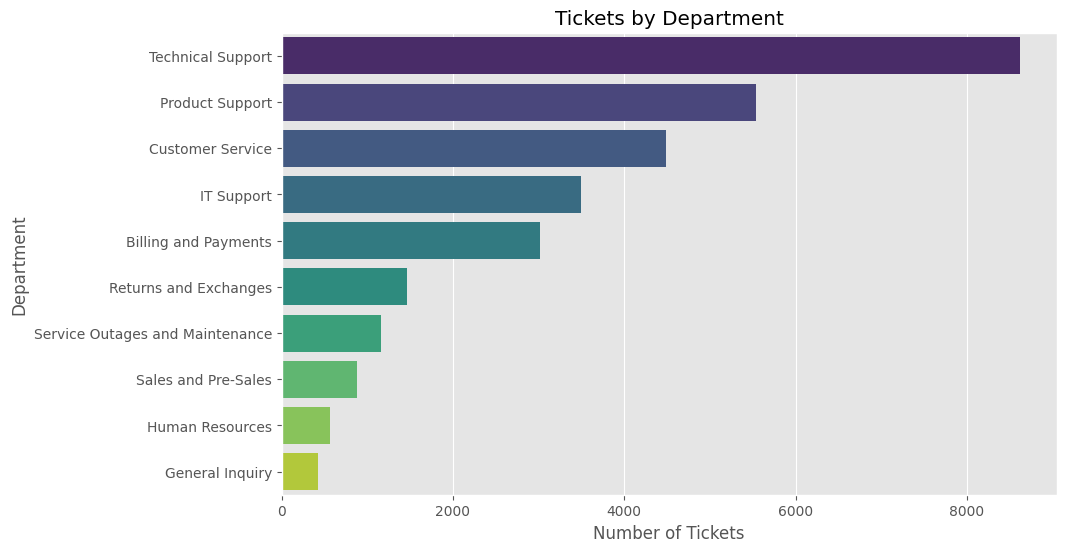

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Department",
    order=df["Department"].value_counts().index,
    palette="viridis"
)

plt.title("Tickets by Department")
plt.xlabel("Number of Tickets")
plt.ylabel("Department")

plt.show()

### Business Insight

Technical Support received the highest number of support tickets (8,617), indicating the greatest operational workload.

**Recommendation**

Increase staffing or automate repetitive requests to improve response time.

## Analysis 2: Ticket Priority Distribution

In [ ]:
priority_count=df["Priority"].value_counts()

priority_count

,count
Priority,
medium,12126
high,11512
low,6013


/tmp/ipykernel_777/2429828299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


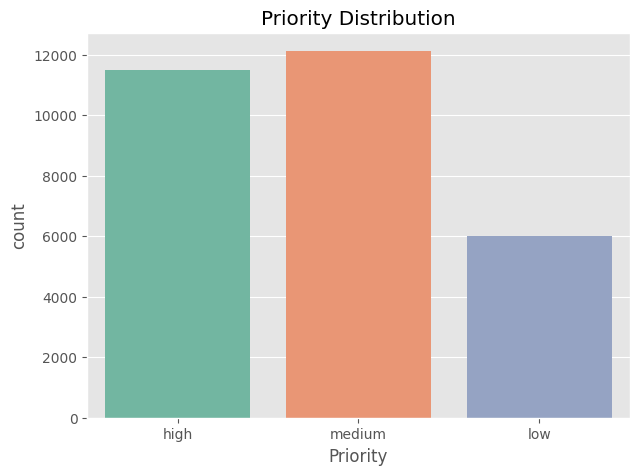

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Priority",
    palette="Set2"
)

plt.title("Priority Distribution")

plt.show()

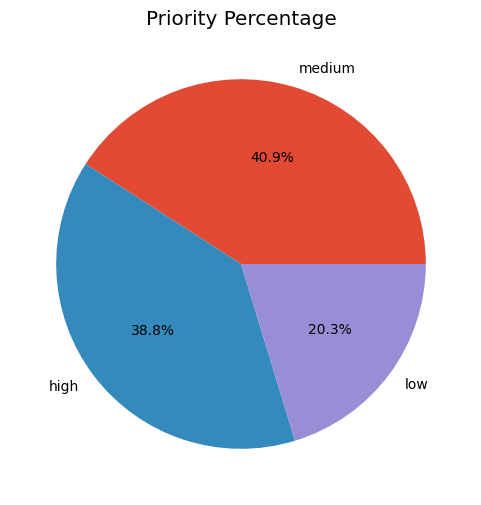

In [ ]:
priority_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Priority Percentage")

plt.show()

### Business Insight

Medium-priority tickets represent the largest share of all requests.

**Recommendation**

Automating medium-priority requests can reduce workload and improve response time for high-priority tickets.

## Analysis 3: Department-wise Priority Analysis

In [ ]:
cross=pd.crosstab(
    df["Department"],
    df["Priority"]
)

cross

Priority,high,low,medium
Department,,,
Billing and Payments,886,632,1499
Customer Service,828,1464,2190
General Inquiry,66,246,107
Human Resources,59,271,238
IT Support,1657,347,1496
Product Support,1682,1048,2809
Returns and Exchanges,328,546,593
Sales and Pre-Sales,154,323,408
Service Outages and Maintenance,818,143,196


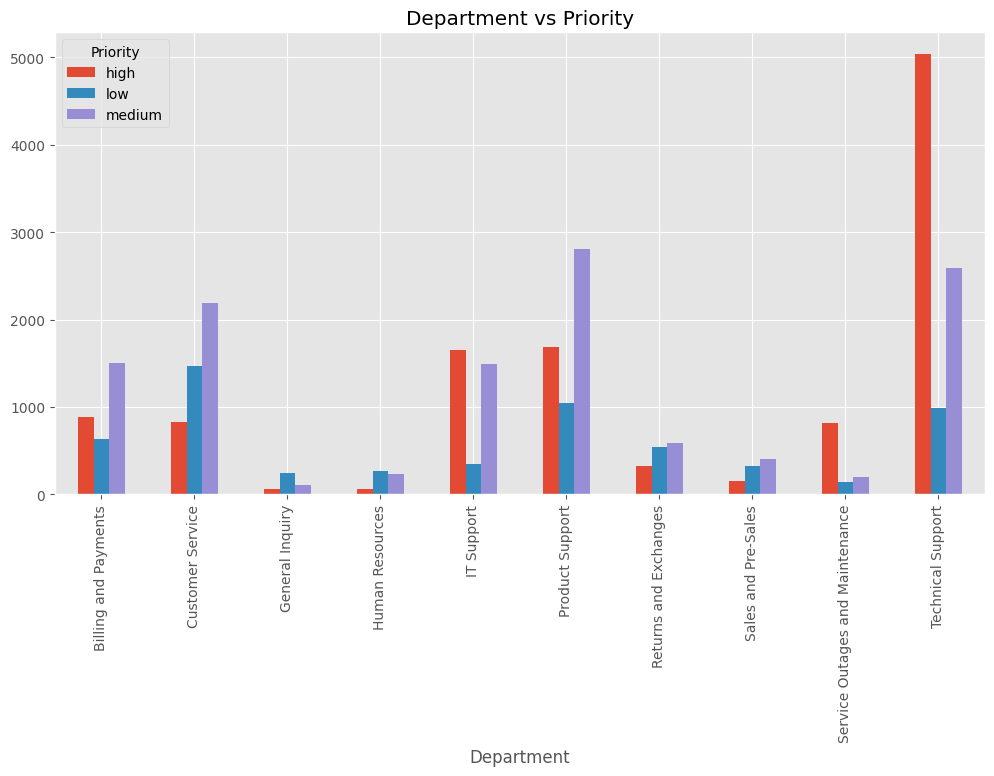

In [ ]:
cross.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Department vs Priority")

plt.show()


### Business Insight

Technical Support handles the highest number of high-priority tickets, indicating that it manages the most critical issues.

**Recommendation**

Allocate additional engineers to the Technical Support department.

## Analysis 4: Department-wise Ticket Percentage

In [ ]:
department_percent = (
df["Department"]
.value_counts(normalize=True)
*100
)

department_percent

,proportion
Department,
Technical Support,29.061414
Product Support,18.680652
Customer Service,15.115848
IT Support,11.803986
Billing and Payments,10.175036
Returns and Exchanges,4.947557
Service Outages and Maintenance,3.902061
Sales and Pre-Sales,2.984722
Human Resources,1.915618


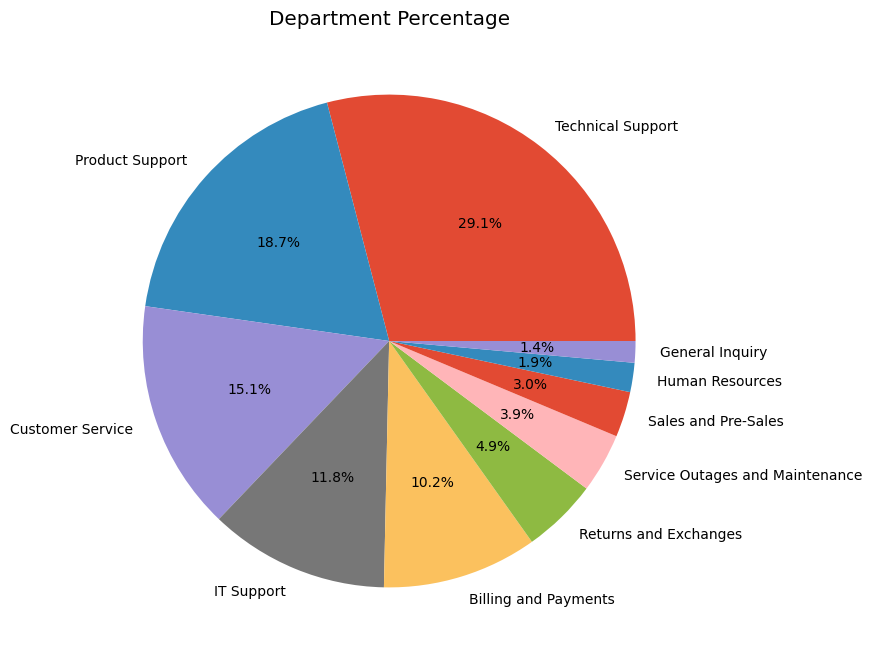

In [ ]:
department_percent.plot(
kind="pie",
autopct="%1.1f%%",
figsize=(8,8)
)

plt.ylabel("")

plt.title("Department Percentage")

plt.show()

### Business Insight

Technical Support contributes the largest percentage of total tickets, followed by Product Support and Customer Service.

This highlights where the majority of operational workload is concentrated.

In [ ]:
priority_percent = (
df["Priority"]
.value_counts(normalize=True)
*100
)

priority_percent

,proportion
Priority,
medium,40.895754
high,38.824997
low,20.279249


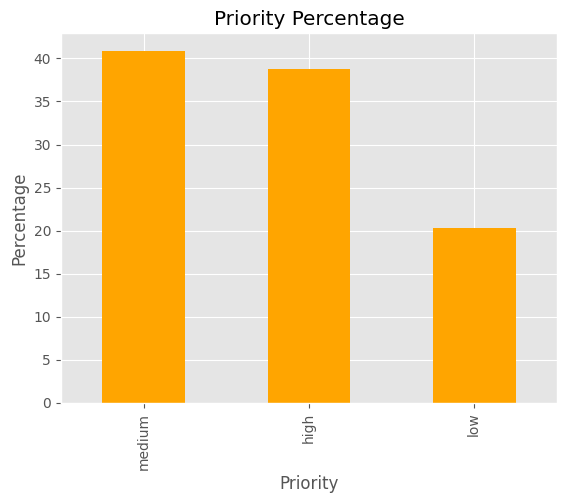

In [ ]:
priority_percent.plot(
kind="bar",
color="orange"
)

plt.title("Priority Percentage")

plt.ylabel("Percentage")

plt.show()

In [ ]:
tag_count=tags["Tags"].value_counts()

tag_count.head(20)

,count
Tags,
Tech Support,14152
IT,13993
Performance,11410
Feedback,8716
Documentation,7644
Bug,7532
Security,6596
Feature,5777
Disruption,4244


/tmp/ipykernel_777/249371435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


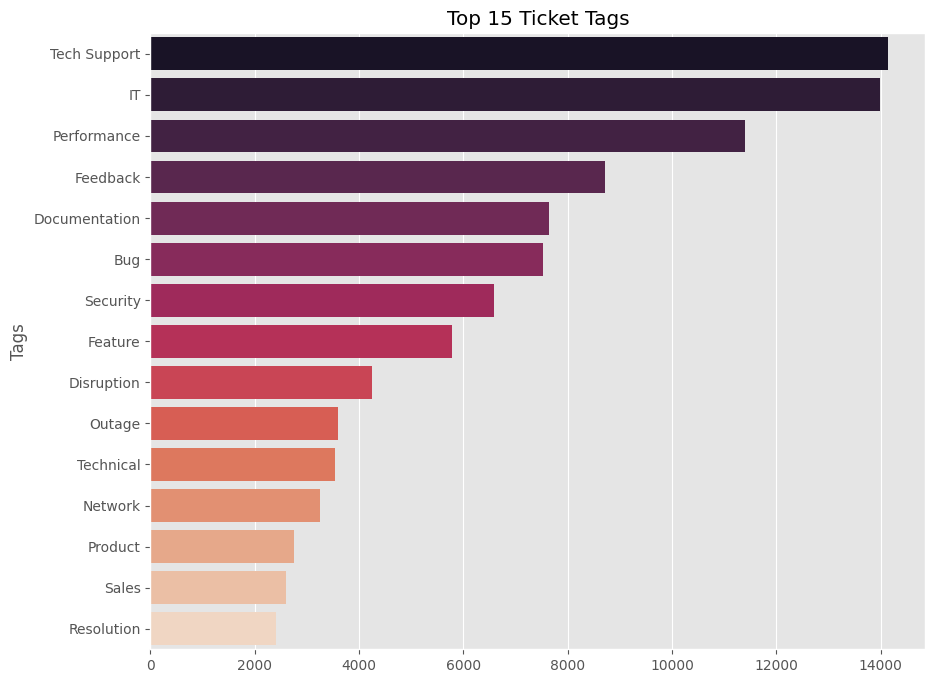

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    x=tag_count.head(15).values,
    y=tag_count.head(15).index,
    palette="rocket"
)

plt.title("Top 15 Ticket Tags")

plt.show()

In [ ]:
department_count.mean()

np.float64(2965.1)

In [ ]:
department_count.idxmax()

'Technical Support'

In [ ]:
department_count.idxmin()

'General Inquiry'

In [ ]:
priority_percentage=(
    df["Priority"]
    .value_counts(normalize=True)
    *100
)

priority_percentage

,proportion
Priority,
medium,40.895754
high,38.824997
low,20.279249


# Conclusion

## Summary of Findings

- The dataset contains 29,651 IT helpdesk tickets.
- Technical Support received the highest number of tickets.
- Medium-priority tickets were the most common.
- Technical Support handled the highest number of high-priority requests.

## Recommendations

- Increase staffing in Technical Support.
- Automate repetitive medium-priority requests.
- Monitor departments with consistently high ticket volumes.

## Export Cleaned Dataset

In [ ]:
df.to_csv(
    "cleaned_ticket.csv",
    index=False
)

In [ ]:
department_count.to_csv(
    "department_ticket_count.csv"
)

In [ ]:
priority_count.to_csv(
    "priority_distribution.csv"
)

In [ ]:
tag_count.to_csv(
    "tag_count.csv"
)

In [ ]:
df.to_csv("clean_ticket.csv", index=False)

print("Clean dataset exported successfully.")

Clean dataset exported successfully.


In [ ]:
df.to_csv(
"/content/drive/MyDrive/IT Helpdesk Analytics/clean_ticket.csv",
index=False
)

# Conclusion

### Key Findings

• Technical Support generated the highest number of tickets.

• Medium priority tickets were the most common.

• Technical Support also handled the largest number of high-priority issues.

### Recommendations

• Increase staffing for Technical Support.

• Automate repetitive medium-priority tickets.

• Monitor departments with increasing ticket volumes.